Taux de compression: 72.57513888888889


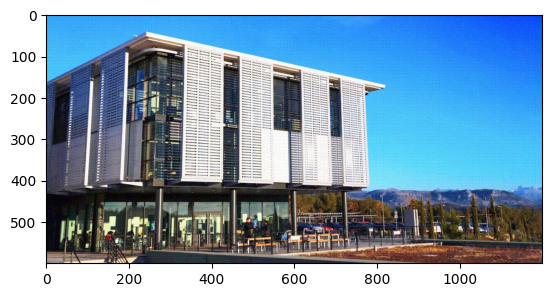

L'erreur relative globale est : 8.256021838763578
L'erreur relative pour la composante bleue est : 6.518191107112583
L'erreur relative pour la composante verte est : 8.820904272857593
L'erreur relative pour la composante rouge est : 10.780984390850312


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import math

#INITIALISATION
A=plt.imread('pns_original.png')
x,y,z=A.shape
x_new=(x//8)*8
y_new=(y//8)*8
img=A[:x_new, :y_new, :z]

#COULEUR
imgb=img[:,:,2]
imgv=img[:,:,1]
imgr=img[:,:,0]

#CENTRE
imgb=(imgb*255).astype(np.int16)-128
imgv=(imgv*255).astype(np.int16)-128
imgr=(imgr*255).astype(np.int16)-128

#DEFINITION DE P ET Q
P=np.zeros((8,8))
for k in range(8):
    for l in range(8):
        if k==0:
            P[k,l]=(1/2)*1/(math.sqrt(2))
        else:
            P[k,l]=(1/2)*math.cos(((2*l+1)*k*math.pi)/16)

Q=np.array([[16,11,10,16,24,40,51,61],[12,12,13,19,26,58,60,55],[14,13,16,24,40,57,69,56],[14,17,22,29,51,87,80,62],[18,22,37,56,68,109,103,77],[24,35,55,64,81,104,113,92],[49,64,78,87,103,121,120,101],[72,92,95,98,112,100,103,99]])


#COMPRESSION
P_inv = np.transpose(P)
F=7
M_compressb=np.zeros((x_new, y_new))
M_compressv=np.zeros((x_new, y_new))
M_compressr=np.zeros((x_new, y_new))
for x in range(0, x_new, 8):
    for y in range(0, y_new, 8):
        bloc1b=imgb[x:x+8, y:y+8]
        bloc2v=imgv[x:x+8, y:y+8]
        bloc3r=imgr[x:x+8, y:y+8]
        new_blocb=np.floor(np.divide(P @ bloc1b @ P_inv,Q)).astype(int)
        new_blocv=np.floor(np.divide(P @ bloc2v @ P_inv,Q)).astype(int)
        new_blocr=np.floor(np.divide(P @ bloc3r @ P_inv,Q)).astype(int)
        for i in range(0,8): #filtrage des hautes fréquences
            for j in range(0,8):
                if (i+j)>=F:
                    new_blocb[i,j]=0
                    new_blocv[i,j]=0
                    new_blocr[i,j]=0
        M_compressb[x:x+8, y:y+8] = new_blocb
        M_compressv[x:x+8, y:y+8] = new_blocv
        M_compressr[x:x+8, y:y+8] = new_blocr

M_final_compress = np.zeros((x_new, y_new, 3))

# Ajouter les canaux rouge, vert et bleu
M_final_compress[:, :, 0] = M_compressr  # Rouge
M_final_compress[:, :, 1] = M_compressv  # Vert
M_final_compress[:, :, 2] = M_compressb  # Bleu


#DECOMPRESSION
M_decompressb=np.zeros((x_new,y_new))
M_decompressv=np.zeros((x_new,y_new))
M_decompressr=np.zeros((x_new,y_new))
for x in range(0, x_new, 8):
    for y in range(0, y_new, 8):
        bloc_compress1b=(M_compressb[x:x+8, y:y+8]*Q)
        bloc_compress2v=(M_compressv[x:x+8, y:y+8]*Q)
        bloc_compress3r=(M_compressr[x:x+8, y:y+8]*Q)
        new_bloc1b=np.clip((P_inv @ bloc_compress1b @ P)+128,0,255).astype(np.uint8)
        new_bloc2v=np.clip((P_inv @ bloc_compress2v @ P)+128,0,255).astype(np.uint8)
        new_bloc3r=np.clip((P_inv @ bloc_compress3r @ P)+128,0,255).astype(np.uint8)
        M_decompressb[x:x+8, y:y+8] = new_bloc1b
        M_decompressv[x:x+8, y:y+8] = new_bloc2v
        M_decompressr[x:x+8, y:y+8] = new_bloc3r

M_final = np.zeros((x_new, y_new, 3), dtype=np.uint8)

# Ajouter les canaux rouge, vert et bleu
M_final[:, :, 0] = M_decompressr  # Rouge
M_final[:, :, 1] = M_decompressv  # Vert
M_final[:, :, 2] = M_decompressb  # Bleu

M_final = M_final/255

# Taux de compression
nb_nonzeros=np.count_nonzero(M_final_compress) #nombre de coeffs non-nuls dans la matrice compressée
taux_de_compression = (1-(nb_nonzeros / img.size)) * 100
print(f"Taux de compression: {taux_de_compression}")

# Afficher l'image finale
plt.imshow(M_final)
plt.show()

#Calcul norme/erreur
norme=np.linalg.norm(img[:,:,:3]-M_final)/np.linalg.norm(img[:,:,:3])
print(f"L'erreur relative globale est : {norme*100}")

#Calcul norme/erreur pour chaque canal de couleur
normeb=np.linalg.norm(np.clip(imgb+128,0,255).astype(np.uint8)-M_decompressb)/np.linalg.norm(np.clip(imgb+128,0,255).astype(np.uint8))
normev=np.linalg.norm(np.clip(imgv+128,0,255).astype(np.uint8)-M_decompressv)/np.linalg.norm(np.clip(imgv+128,0,255).astype(np.uint8))
normer=np.linalg.norm(np.clip(imgr+128,0,255).astype(np.uint8)-M_decompressr)/np.linalg.norm(np.clip(imgr+128,0,255).astype(np.uint8))
print(f"L'erreur relative pour la composante bleue est : {normeb*100}")
print(f"L'erreur relative pour la composante verte est : {normev*100}")
print(f"L'erreur relative pour la composante rouge est : {normer*100}")